In [1]:
!pip install scikit-bio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 74.9 MB/s eta 0:00:00


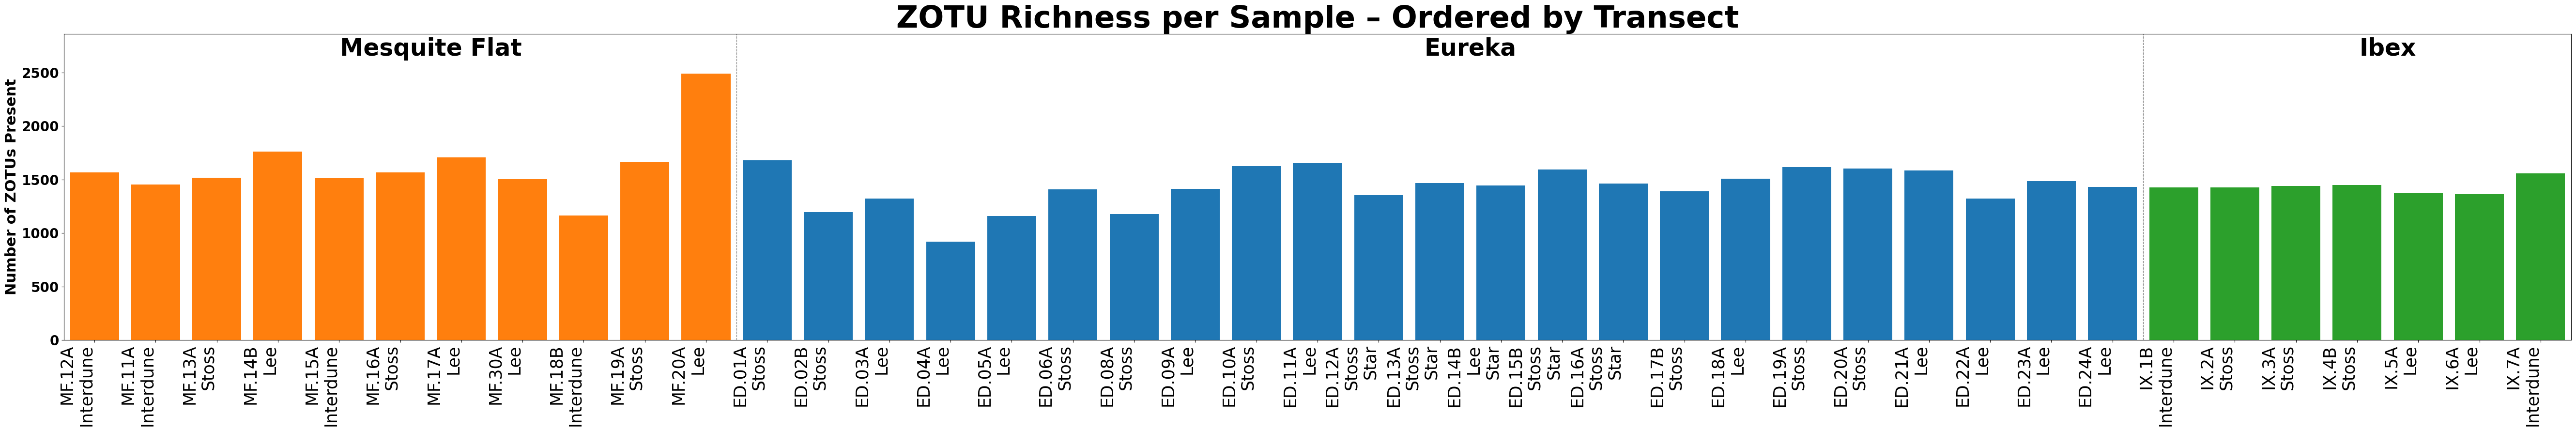

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ───────────────────────────────────────
# 0″  DEFINE YOUR TRANSECTS  (edit order here if desired)
# ───────────────────────────────────────
#mesquite_north = ["MF.33A","MF.4B","MF.5B","MF.6B","MF.7B","MF.8B",MF.27B]
mesquite= [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A",
    "MF.16A","MF.17A","MF.30A","MF.18B","MF.19A","MF.20A"
]
eumod_transect = [
    "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A","ED.08A",
    "ED.09A","ED.10A","ED.11A","ED.12A","ED.13A","ED.14B","ED.15B",
    "ED.16A","ED.17B","ED.18A","ED.19A","ED.20A","ED.21A",
    "ED.22A","ED.23A","ED.24A"
]
ibex_transect = [
    "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A","IX.6A","IX.7A"
]

transects_ordered = [
#    ("Mesquite North", mesquite_north, "tab:red"),
    ("Mesquite Flat", mesquite, "tab:orange"),
    ("Eureka",         eumod_transect, "tab:blue"),
    ("Ibex",           ibex_transect,   "tab:green")
]

# ───────────────────────────────────────
# 1″  LOAD COUNT TABLE  (row-0 = anatomy, row-1 = header)
# ───────────────────────────────────────
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

sample_cols = df.columns[1:-7]                       # exclude Zotu + taxonomy
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ZOTU richness per sample
zotu_rich = (df[sample_cols] > 0).astype(int).sum(axis=0)

# Helper function to format anatomy labels
def _format_anatomy_label(label):
    if isinstance(label, str):
        label = label.replace(', Depth', '\nDepth')
        label = label.replace('_Depth', '\nDepth')
        label = label.replace(', ', '\n')
    return label

# label map: "Sample\nAnatomy"
label_map = {
    s: f"{s}\n{_format_anatomy_label(anatomy_row[df.columns.get_loc(s)])}"
    for s in sample_cols
}

# ───────────────────────────────────────
# 2″  BUILD ORDERED LIST OF SAMPLES & COUNTS
# ───────────────────────────────────────
ordered_samples = []
bar_colors      = []
section_bounds  = []          # to draw separator lines

for name, sample_list, color in transects_ordered:
    keep = [s for s in sample_list if s in zotu_rich.index]
    ordered_samples.extend(keep)
    bar_colors.extend([color] * len(keep))
    section_bounds.append(len(ordered_samples))      # boundary after this block

counts  = zotu_rich[ordered_samples]
labels  = [label_map[s] for s in ordered_samples]

# ───────────────────────────────────────
# 3″  PLOT
# ───────────────────────────────────────
plt.figure(figsize=(max(len(labels)*1.3, 19), 9))

plt.bar(range(len(counts)), counts.values, color=bar_colors)

# vertical separators between transects
for bound in section_bounds[:-1]:
    plt.axvline(bound - 0.5, color='gray', linestyle='--', linewidth=0.9)

# add group labels above
midpoints = [section_bounds[0]/2]
for i in range(1, len(section_bounds)):
    midpoints.append((section_bounds[i-1] + section_bounds[i]) / 2)

for midpoint, (name, _, _) in zip(midpoints, transects_ordered):
    plt.text(midpoint, max(counts)*1.05, name, ha='center', va='bottom', fontsize=35, weight='bold')

plt.xticks(range(len(labels)), labels, rotation=90, ha='right', fontsize=25) # Adjusted fontsize to 10
plt.yticks(fontsize=20, fontweight='bold') # Added to increase y-axis label size
plt.ylabel("Number of ZOTUs Present",fontsize= '22', fontweight='bold')
plt.title("ZOTU Richness per Sample – Ordered by Transect",fontsize= '45', fontweight='bold')
plt.ylim(0, max(counts)*1.15)
plt.xlim(-0.5, len(labels) - 0.5)
plt.tight_layout()
plt.show()

### Minimum and Maximum ZOTU Richness by Transect

In [3]:
#GET TRANSECT DIFFERENCES FROM CSV
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "/content/DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

All parsed sample IDs:
                  Sample Name: SampleID        Lat        Lon
0    MESQUITE FLATS SAND MF-4B    MF.4B  36.616170 -117.11751
1    MESQUITE FLATS SAND MF-5B    MF.5B  36.614740 -117.11369
2    MESQUITE FLATS SAND MF-6B    MF.6B  36.614722 -117.11330
3    MESQUITE FLATS SAND MF-7B    MF.7B  36.613910 -117.11299
4    MESQUITE FLATS SAND MF-8B    MF.8B  36.613910 -117.11299
5   MESQUITE FLATS SAND MF-11A   MF.11A  36.615590 -117.12206
6   MESQUITE FLATS SAND MF-12A   MF.12A  36.615590 -117.12206
7   MESQUITE FLATS SAND MF-13A   MF.13A  36.614190 -117.12077
8   MESQUITE FLATS SAND MF-14B   MF.14B  36.613910 -117.12043
9   MESQUITE FLATS SAND MF-15A   MF.15A  36.613540 -117.12106
10  MESQUITE FLATS SAND MF-16A   MF.16A  36.612890 -117.11925
11  MESQUITE FLATS SAND MF-17A   MF.17A  36.612530 -117.11896
12  MESQUITE FLATS SAND MF-18B   MF.18B  36.612180 -117.11875
13  MESQUITE FLATS SAND MF-19A   MF.19A  36.612100 -117.11831
14  MESQUITE FLATS SAND MF-20A   MF.20A  36.611

Prokaryotic ZOTUs: 5892
Alpha diversity computed for 52 samples


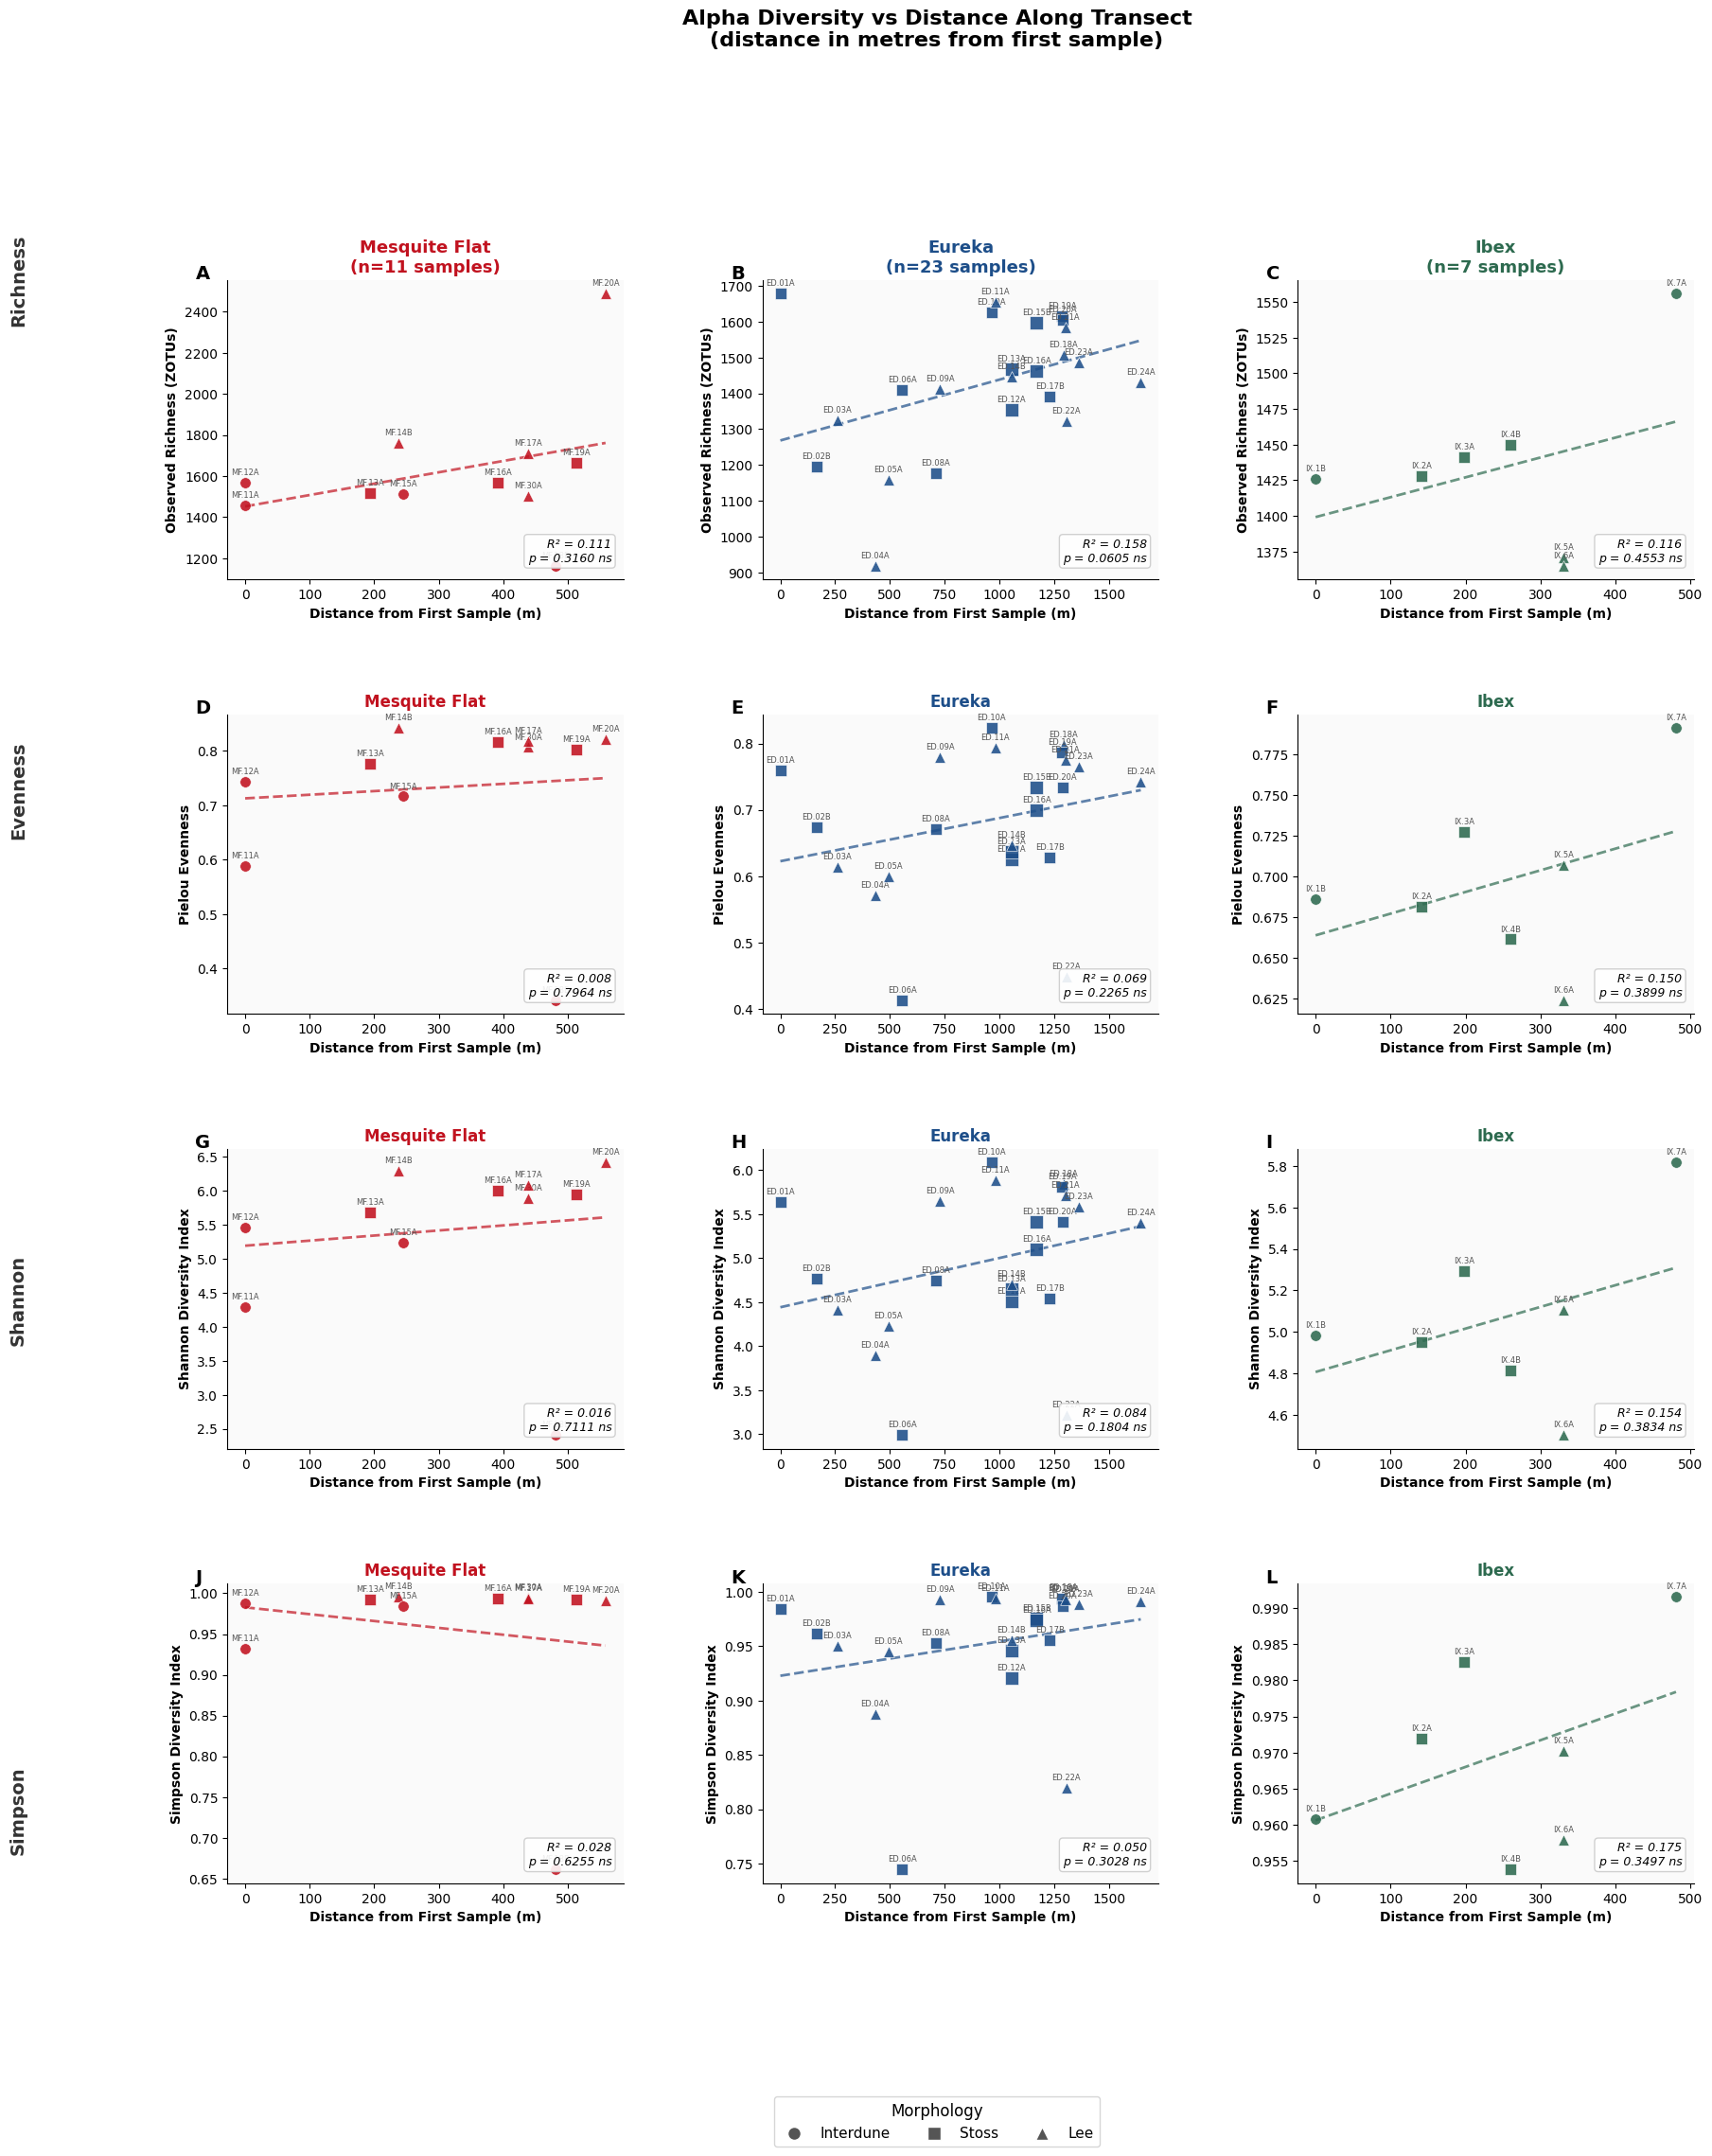

In [4]:
#ALPHA DIVERSITY BY TRANSECT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ============================
# LOAD COUNT FILE
# use raw counts not relative abundance for alpha diversity
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()

# filter prokaryotes only
micro = df[
    df["Domain"].isin(["bacteria", "archaea"])
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# ALPHA DIVERSITY FUNCTIONS
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

# ============================
# COMPUTE ALPHA PER SAMPLE
# ============================
records = []
for s in sample_cols:
    counts                           = micro[s].values.astype(float)
    shannon, simpson, evenness, rich = compute_alpha(counts)
    records.append({
        "Sample":   s,
        "Richness": rich,
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
    })

alpha_df = pd.DataFrame(records).set_index("Sample")
print(f"Alpha diversity computed for {len(alpha_df)} samples")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

metrics = [
    ("Richness", "Observed Richness (ZOTUs)"),
    ("Evenness", "Pielou Evenness"),
    ("Shannon",  "Shannon Diversity Index"),
    ("Simpson",  "Simpson Diversity Index"),
]

# ============================
# COMPUTE DISTANCES FROM
# FIRST SAMPLE IN EACH TRANSECT
# uses coord_map and haversine_m
# from previous cell
# ============================
def get_transect_distances(sample_list, coord_map):
    valid = [s for s in sample_list
             if s in coord_map and s in alpha_df.index]
    if len(valid) == 0:
        return [], []

    anchor_lat = coord_map[valid[0]]["Lat"]
    anchor_lon = coord_map[valid[0]]["Lon"]

    distances = []
    samples   = []
    for s in valid:
        lat  = coord_map[s]["Lat"]
        lon  = coord_map[s]["Lon"]
        dist = haversine_m(anchor_lat, anchor_lon, lat, lon)
        distances.append(dist)
        samples.append(s)

    return distances, samples

# ============================
# ANATOMY MAP for markers
# ============================
anatomy_map = {}
col_list    = list(df.columns)
for s in sample_cols:
    try:
        col_idx        = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

MORPH_STYLE = {
    "Interdune":        ("o", 70),
    "Stoss":            ("s", 65),
    "Lee":              ("^", 70),
    "Stoss, Depth":     ("s", 65),
    "Stoss , Depth":    ("s", 65),
    "Interdune, Depth": ("o", 65),
    "Stoss, Star":      ("s", 95),
    "Stoss , Star":     ("s", 95),
    "Lee, Star":        ("^", 70),
    "Stoss, Crest":     ("s", 65),
}

# ============================
# FIGURE
# 4 rows (metrics) x 3 cols (fields)
# ============================
fig, axes = plt.subplots(
    4, 3, figsize=(20, 22),
    gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.patch.set_facecolor("white")

field_names  = list(transects.keys())
panel_labels = "ABCDEFGHIJKL"
panel_idx    = 0

for mi, (metric, ylabel) in enumerate(metrics):
    for fi, field in enumerate(field_names):
        ax    = axes[mi, fi]
        color = field_colors[field]

        distances, samps = get_transect_distances(
            transects[field], coord_map)

        if len(distances) == 0:
            ax.set_title(f"{field} — {metric}\n(no data)")
            continue

        values = [alpha_df.loc[s, metric] for s in samps]

        # scatter with morphology markers
        for d, v, s in zip(distances, values, samps):
            anat   = anatomy_map.get(s, "Interdune")
            mk, sz = MORPH_STYLE.get(anat, ("o", 70))
            ax.scatter(d, v, color=color,
                       marker=mk, s=sz,
                       edgecolors="white",
                       linewidths=0.5,
                       alpha=0.88, zorder=3)
            ax.annotate(s, (d, v),
                        textcoords="offset points",
                        xytext=(0, 6),
                        fontsize=6, ha="center",
                        color="#555555")

        # regression line + stats
        if len(distances) > 2:
            slope, intercept, r_val, p_val, _ = linregress(
                distances, values)
            r2   = r_val ** 2
            x_ln = np.linspace(min(distances),
                                max(distances), 200)
            ax.plot(x_ln,
                    slope * x_ln + intercept,
                    color=color, linewidth=2,
                    linestyle="--", alpha=0.7)

            sig = ("***" if p_val < 0.001 else
                   "**"  if p_val < 0.01  else
                   "*"   if p_val < 0.05  else "ns")

            ax.text(0.97, 0.05,
                    f"R² = {r2:.3f}\n"
                    f"p = {p_val:.4f} {sig}",
                    transform=ax.transAxes,
                    ha="right", va="bottom",
                    fontsize=9, style="italic",
                    bbox=dict(boxstyle="round,pad=0.3",
                              facecolor="white",
                              edgecolor="#cccccc",
                              alpha=0.9))

        # panel label
        ax.text(-0.08, 1.05, panel_labels[panel_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")

        # titles and labels
        if mi == 0:
            ax.set_title(
                f"{field}\n(n={len(samps)} samples)",
                fontsize=13, fontweight="bold",
                color=color)
        else:
            ax.set_title(
                f"{field}",
                fontsize=12, fontweight="bold",
                color=color)

        ax.set_xlabel("Distance from First Sample (m)",
                      fontsize=10, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=10,
                      fontweight="bold")
        ax.tick_params(labelsize=10)
        ax.set_facecolor("#fafafa")
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)

        panel_idx += 1

# ============================
# ROW LABELS
# ============================
row_labels = ["Richness", "Evenness",
              "Shannon", "Simpson"]
for mi, label in enumerate(row_labels):
    fig.text(0.01, 0.88 - mi * 0.245, label,
             fontsize=14, fontweight="bold",
             va="center", rotation=90,
             color="#333333")

# ============================
# MORPHOLOGY LEGEND
# ============================
import matplotlib.lines as mlines

morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Lee"),
]

fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=11, title_fontsize=12,
    frameon=True, edgecolor="#cccccc"
)

fig.suptitle(
    "Alpha Diversity vs Distance Along Transect\n"
    "(distance in metres from first sample)",
    fontsize=16, fontweight="bold", y=1.01)
plt.show()


ZOTU richness calculated for 52 samples


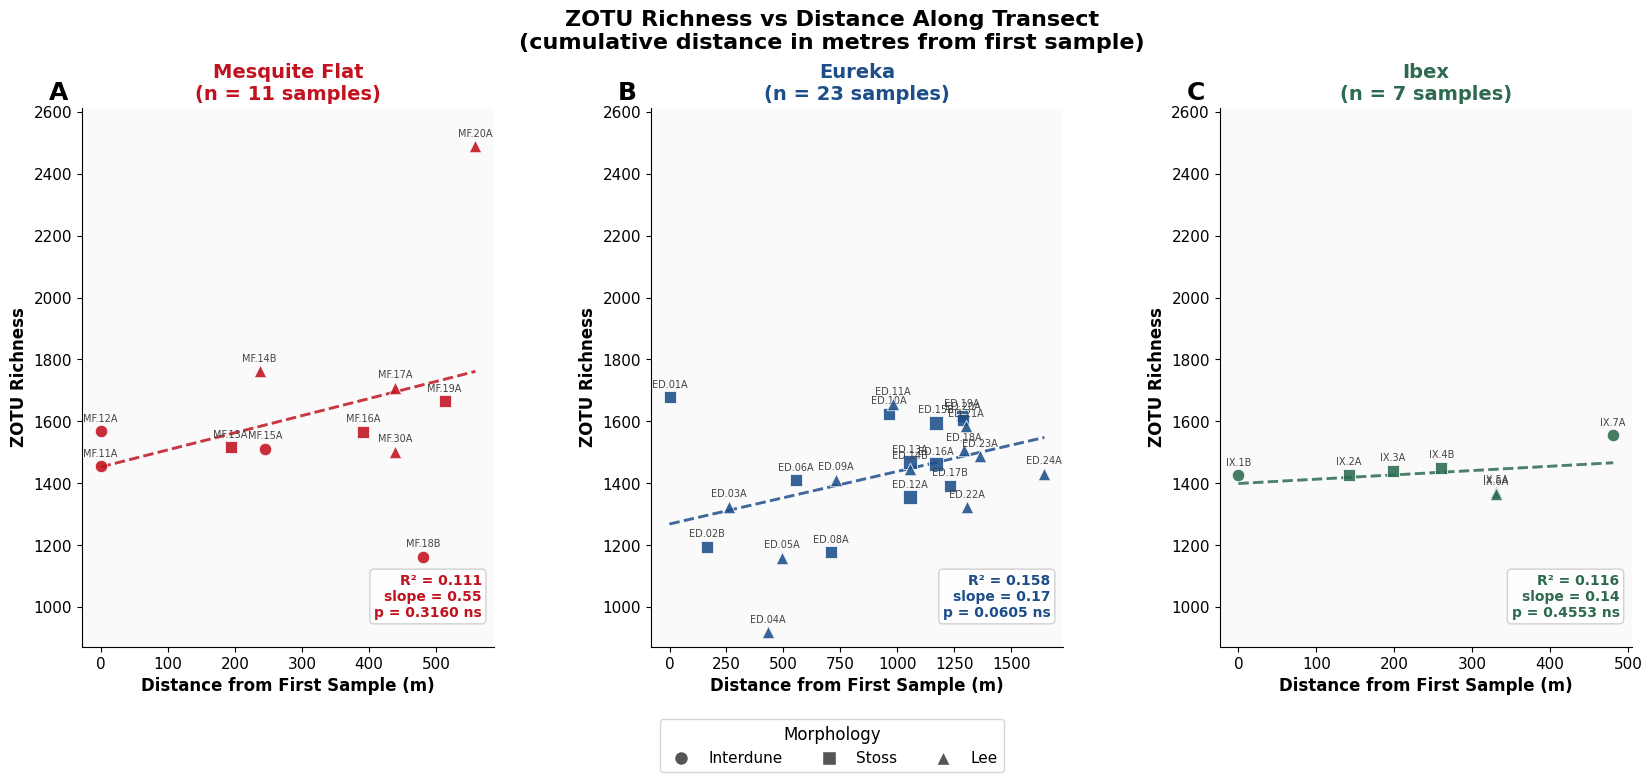

In [5]:
#richness along transect with x=distance y= richness

# ============================
# LOAD COUNT TABLE
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in df.columns[1:-7]
               if "Blank" not in str(c)]
df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

zotu_rich = (df[sample_cols] > 0).astype(int).sum(axis=0)

print(f"ZOTU richness calculated for {len(zotu_rich)} samples")

# ============================
# ANATOMY MAP
# ============================
anatomy_map = {}
col_list    = list(df.columns)
for s in sample_cols:
    try:
        col_idx          = col_list.index(s)
        anatomy_map[s]   = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s]   = "Interdune"

# ============================
# TRANSECT DEFINITIONS
# ============================
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]
eureka = [
    "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
    "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
    "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
    "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
]
ibex = [
    "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
    "IX.6A","IX.7A"
]

transects = [
    ("Mesquite Flat", mesquite, "#c1121f"),
    ("Eureka",        eureka,   "#1d4e89"),
    ("Ibex",          ibex,     "#2d6a4f"),
]

# ============================
# MORPH STYLE
# 3 symbols only
# ============================
MORPH_STYLE = {
    "Interdune":        ("o", 80),
    "Stoss":            ("s", 75),
    "Lee":              ("^", 80),
    "Stoss, Depth":     ("s", 75),
    "Stoss , Depth":    ("s", 75),
    "Interdune, Depth": ("o", 75),
    "Stoss, Star":      ("s", 110),
    "Stoss , Star":     ("s", 110),
    "Lee, Star":        ("^", 80),
    "Stoss, Crest":     ("s", 75),
}

# ============================
# COMPUTE DISTANCES
# from first sample in each transect
# ============================
def compute_distances(sample_list, coord_map, zotu_rich):
    distances = []
    richness  = []
    labels    = []

    valid = [s for s in sample_list
             if s in coord_map and s in zotu_rich.index]

    if len(valid) == 0:
        return [], [], []

    anchor_lat = coord_map[valid[0]]["Lat"]
    anchor_lon = coord_map[valid[0]]["Lon"]

    for s in valid:
        lat  = coord_map[s]["Lat"]
        lon  = coord_map[s]["Lon"]
        dist = haversine_m(anchor_lat, anchor_lon, lat, lon)
        distances.append(dist)
        richness.append(zotu_rich[s])
        labels.append(s)

    return distances, richness, labels

# ============================
# FIGURE — one panel per transect
# ============================
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                          gridspec_kw={"wspace": 0.38})
fig.patch.set_facecolor("white")

# compute shared y axis limits
all_richness = []
for _, slist, _ in transects:
    _, r, _ = compute_distances(slist, coord_map, zotu_rich)
    all_richness.extend(r)

y_min = min(all_richness) * 0.95
y_max = max(all_richness) * 1.05

panel_labels = "ABC"

for ax, (name, sample_list, color), panel_lbl in zip(
        axes, transects, panel_labels):

    distances, richness, labels = compute_distances(
        sample_list, coord_map, zotu_rich)

    if len(distances) == 0:
        ax.set_title(f"{name}\n(no data)", fontsize=14)
        continue

    # scatter with morphology markers
    for d, r, s in zip(distances, richness, labels):
        anat   = anatomy_map.get(s, "Interdune")
        mk, sz = MORPH_STYLE.get(anat, ("o", 80))
        ax.scatter(d, r, color=color, marker=mk, s=sz,
                   edgecolors="white", linewidths=0.6,
                   alpha=0.88, zorder=3)

        # sample label
        ax.annotate(s, (d, r),
                    textcoords="offset points",
                    xytext=(0, 7),
                    fontsize=7, ha="center",
                    color="#444444")

    # trend line
    if len(distances) > 2:
        z    = np.polyfit(distances, richness, 1)
        p    = np.poly1d(z)
        x_ln = np.linspace(min(distances),
                            max(distances), 200)
        ax.plot(x_ln, p(x_ln), color=color,
                linewidth=2, linestyle="--", alpha=0.6)

    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")

    ax.set_title(f"{name}\n(n = {len(labels)} samples)",
                 fontsize=14, fontweight="bold", color=color)
    ax.set_xlabel("Distance from First Sample (m)",
                  fontsize=12, fontweight="bold")
    ax.set_ylabel("ZOTU Richness", fontsize=12,
                  fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.tick_params(labelsize=11)
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

        # trend line + regression stats
    if len(distances) > 2:
        z      = np.polyfit(distances, richness, 1)
        p      = np.poly1d(z)
        x_ln   = np.linspace(min(distances),
                              max(distances), 200)
        ax.plot(x_ln, p(x_ln), color=color,
                linewidth=2, linestyle="--", alpha=0.6)

        # regression stats
        from scipy.stats import pearsonr, linregress
        slope, intercept, r_val, p_val, se = linregress(
            distances, richness)
        r2 = r_val ** 2

        sig = ("***" if p_val < 0.001 else
               "**"  if p_val < 0.01  else
               "*"   if p_val < 0.05  else "ns")

        ax.text(0.97, 0.05,
                f"R² = {r2:.3f}\n"
                f"slope = {slope:.2f}\n"
                f"p = {p_val:.4f} {sig}",
                transform=ax.transAxes,
                ha="right", va="bottom",
                fontsize=10, fontweight="bold",
                color=color,
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="#cccccc",
                          alpha=0.9))

# ============================
# MORPHOLOGY LEGEND
# ============================
morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Lee"),
]

fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=11, title_fontsize=12,
    frameon=True, edgecolor="#cccccc"
)

fig.suptitle(
    "ZOTU Richness vs Distance Along Transect\n"
    "(cumulative distance in metres from first sample)",
    fontsize=16, fontweight="bold", y=1.02)

plt.show()


OTU matrix: 52 samples x 5892 ZOTUs
PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance
Spearman correlation, 999 permutations

Mesquite Flat (n=11 samples found)
  Mantel r = 0.230  R² = 0.053  p = 0.1250  ns

Eureka (n=23 samples found)
  Mantel r = 0.335  R² = 0.112  p = 0.0020  **

Ibex (n=7 samples found)
  Mantel r = 0.594  R² = 0.353  p = 0.0400  *


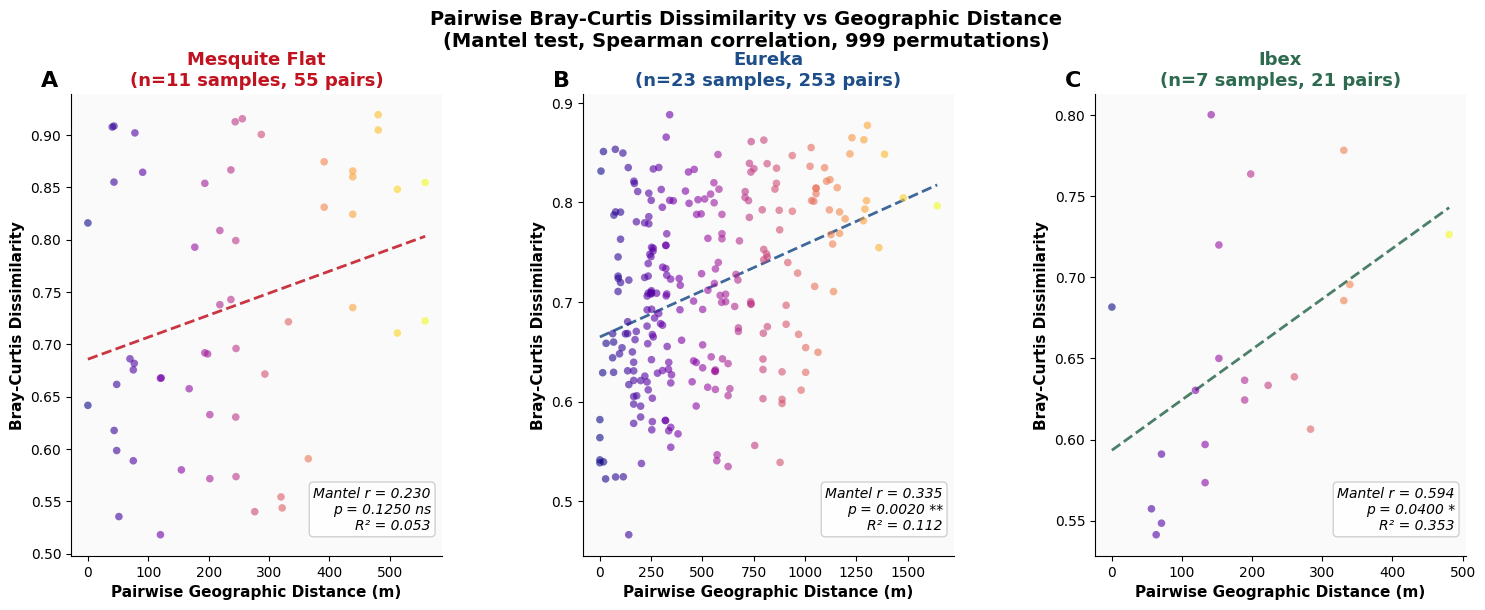

In [6]:
#BRAY CURTIS MANTEL along transect with x=distance y=BRAY CURTIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

# build sample x ZOTU matrix
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

# ============================
# RUN PAIRWISE MANTEL PER FIELD
# x = geographic distance in metres (haversine)
# y = Bray-Curtis dissimilarity
#
# NOTE ON R^2:
# R^2 is now calculated directly from the Mantel Spearman r
# (r_mantel ** 2), NOT from a separately-fit OLS/Pearson
# regression. This keeps r, p, and R^2 internally consistent --
# all three come from the same Spearman-based Mantel statistic.
# The OLS line is retained in the FIGURE ONLY as a visual trend
# aid; its own r/p/R^2 are never computed or reported, since
# pairwise distances are non-independent (each sample appears in
# multiple pairs) and a naive OLS p-value would be invalid here.
# ============================
def run_field_mantel(field, sample_list, otu_df,
                     coord_map, n_perm=999):

    # keep only samples present in both OTU and coord map
    samps = [s for s in sample_list
             if s in otu_df.index and s in coord_map]
    n     = len(samps)

    print(f"\n{field} (n={n} samples found)")

    if n < 4:
        print(f"  Insufficient samples — skipping")
        return None

    # ============================
    # GEOGRAPHIC DISTANCE MATRIX
    # pairwise haversine in metres
    # ============================
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(lat1, lon1,
                                             lat2, lon2)

    # ============================
    # BRAY-CURTIS DISTANCE MATRIX
    # ============================
    sub    = otu_df.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    # ============================
    # MANTEL TEST (Spearman)
    # ============================
    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)

    # R^2 derived directly from the Mantel r (Spearman-based),
    # so r, p, and R^2 are all internally consistent
    r2 = r ** 2

    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    print(f"  Mantel r = {r:.3f}  R² = {r2:.3f}  p = {p:.4f}  {sig}")

    # extract upper triangle for plotting
    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "r2": r2, "p": p, "sig": sig,
        "samps": samps,
        "x_geo": x_geo,
        "y_bc":  y_bc,
        "geo_mat": geo_mat,
        "bc_mat":  bc_mat,
        "n": n
    }

# ============================
# RUN FOR ALL THREE FIELDS
# ============================
print("=" * 55)
print("PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance")
print("Spearman correlation, 999 permutations")
print("=" * 55)

results = {}
for field, slist in transects.items():
    results[field] = run_field_mantel(
        field, slist, otu, coord_map, n_perm=999)

# ============================
# FIGURE
# one panel per field
# x = geographic distance (m)
# y = Bray-Curtis dissimilarity
#
# The dashed regression line is a VISUAL TREND AID ONLY
# (fit via simple OLS for a smooth line to look at).
# It is intentionally NOT used as the source of any
# reported statistic -- all reported numbers (r, R^2, p)
# come from the Mantel test above.
# ============================
fields  = [f for f in transects if results[f] is not None]
fig, axes = plt.subplots(1, len(fields),
                          figsize=(6 * len(fields), 6),
                          gridspec_kw={"wspace": 0.38})
fig.patch.set_facecolor("white")

if len(fields) == 1:
    axes = [axes]

panel_labels = "ABC"

for ax, field, panel_lbl in zip(axes, fields, panel_labels):
    res   = results[field]
    color = field_colors[field]

    x = res["x_geo"]
    y = res["y_bc"]

    # colour points by distance
    sc = ax.scatter(x, y, c=x, cmap="plasma",
                    alpha=0.6, s=30, linewidths=0,
                    vmin=x.min(), vmax=x.max(),
                    zorder=3)

    # regression line -- visual aid only, not a reported statistic
    slope, intercept, _, _, _ = linregress(x, y)
    x_ln = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_ln, slope * x_ln + intercept,
            color=color, linewidth=2,
            linestyle="--", alpha=0.85)

    # stats box -- all values sourced from the Mantel test
    ax.text(0.97, 0.05,
            f"Mantel r = {res['r']:.3f}\n"
            f"p = {res['p']:.4f} {res['sig']}\n"
            f"R² = {res['r2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10, style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc",
                      alpha=0.9))

    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")

    ax.set_title(f"{field}\n(n={res['n']} samples, "
                 f"{len(x)} pairs)",
                 fontsize=13, fontweight="bold",
                 color=color)
    ax.set_xlabel("Pairwise Geographic Distance (m)",
                  fontsize=11, fontweight="bold")
    ax.set_ylabel("Bray-Curtis Dissimilarity",
                  fontsize=11, fontweight="bold")
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

fig.suptitle(
    "Pairwise Bray-Curtis Dissimilarity vs Geographic Distance\n"
    "(Mantel test, Spearman correlation, 999 permutations)",
    fontsize=14, fontweight="bold", y=1.02)

plt.show()